In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---------------- Parameters ----------------
IMG_SIZE = (400, 400)   # target size from instructor's suggestion
USERNAME = "username"   # change if they want a specific id shown on plots


def add_username():
    """Write username at top-right of current axes."""
    plt.text(
        0.95, 0.95, USERNAME,
        ha='right', va='top',
        transform=plt.gca().transAxes,
        fontsize=10, color='gray', alpha=0.7
    )


Background shape: (400, 400, 3)
Test shape      : (400, 400, 3)


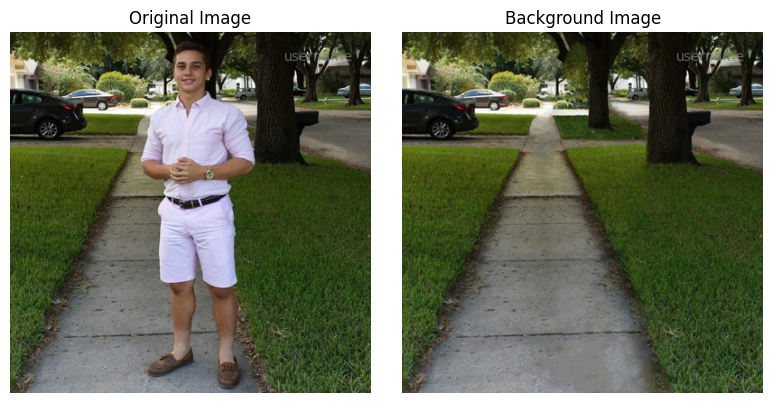

In [3]:
# --------- CHANGE THESE TO YOUR ACTUAL FILE NAMES ---------
background_path = "back.jpg"  # clean background
test_path = "Full.jpg"          # image with person
# ----------------------------------------------------------


def load_and_align_images(bg_path, test_path, size=IMG_SIZE):
    """Load, convert to RGB, and resize both images to the same size."""
    bg_img = Image.open(bg_path).convert("RGB").resize(size)
    test_img = Image.open(test_path).convert("RGB").resize(size)
    return np.asarray(bg_img), np.asarray(test_img)


background_img, test_img = load_and_align_images(
    background_path, test_path, size=IMG_SIZE
)

print("Background shape:", background_img.shape)
print("Test shape      :", test_img.shape)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(test_img)
plt.title("Original Image")
plt.axis("off")
add_username()

plt.subplot(1, 2, 2)
plt.imshow(background_img)
plt.title("Background Image")
plt.axis("off")
add_username()

plt.tight_layout()
plt.show()


In [4]:
# Convert from uint8 [0,255] to float64 [0,1]
bg_rgb = background_img.astype(np.float64) / 255.0
test_rgb = test_img.astype(np.float64) / 255.0

H, W, C = bg_rgb.shape  # should be (400, 400, 3)

# Use RGB as 3-D features: each pixel is [R,G,B]
background_features = bg_rgb.reshape(-1, C)  # shape (N_bg, 3)
test_features = test_rgb.reshape(-1, C)      # shape (N_test, 3)

print("Background features:", background_features.shape)
print("Test features      :", test_features.shape)


Background features: (160000, 3)
Test features      : (160000, 3)


### 1.1 Image Pre-Processing – Justification

**Image alignment and resizing**  
Both the background and test images are loaded, converted to RGB, and resized to the same fixed resolution (`IMG_SIZE`). Converting to RGB gives a consistent 3-channel representation independent of the original file format. Resizing to a common size spatially aligns the two images so that each pixel location in the background corresponds to the same location in the test image. Choosing a moderate resolution balances computational efficiency for later KDE processing with enough detail to clearly see the foreground object.

**Feature representation**  
For KDE we use the RGB color of each pixel as the feature vector: (R, G, B). This keeps the feature space low-dimensional and efficient to model, while still capturing the key visual cue that separates foreground from background: differences in color and intensity. Because the background is mostly static and the foreground object introduces distinct colors, raw RGB features are sufficient and more interpretable than heavier descriptors such as deep features or large patches.


In [5]:
class CustomKDE:
    """
    Simple multivariate KDE using numpy only.

    Parameters
    ----------
    kernel : {"gaussian", "triangular", "uniform"}
        Kernel shape.
    bandwidth : float
        Positive smoothing parameter h.
    data : ndarray, optional
        Optional initial data to fit.
    max_samples : int or None
        Max number of training points stored. If data has more, we randomly
        subsample (smart sampling).
    batch_size : int or None
        If not None, predict() computes densities in batches of this size
        to control memory and runtime.
    random_state : int
        Seed for reproducible subsampling.
    """
    def __init__(self, kernel="gaussian", bandwidth=0.05,
                 data=None, max_samples=15000, batch_size=5000,
                 random_state=0):
        self.kernel = kernel
        self.bandwidth = float(bandwidth)
        if self.bandwidth <= 0:
            raise ValueError("bandwidth must be positive.")
        self.max_samples = max_samples
        self.batch_size = batch_size
        self.random_state = random_state

        self.data = None
        self.n_samples = None
        self.n_features = None

        if data is not None:
            self.fit(data)

    # ---------- internal helpers ----------
    def _check_array(self, X):
        X = np.asarray(X, dtype=np.float64)
        if X.ndim == 1:
            X = X[:, np.newaxis]
        return X

    def _kernel_function(self, distances):
        """
        distances: array >= 0, shape (m, n)
        Returns K(distances) with the chosen kernel.
        """
        if self.kernel == "gaussian":
            return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * distances**2)
        elif self.kernel == "triangular":
            return np.maximum(0.0, 1.0 - distances)
        elif self.kernel == "uniform":
            out = 0.5 * np.ones_like(distances)
            out[distances > 1.0] = 0.0
            return out
        else:
            raise ValueError(f"Unknown kernel '{self.kernel}'")

    # ---------- public methods ----------
    def fit(self, data):
        """Store (and subsample) training data."""
        X = self._check_array(data)

        if self.max_samples is not None and X.shape[0] > self.max_samples:
            rng = np.random.default_rng(self.random_state)
            idx = rng.choice(X.shape[0], size=self.max_samples, replace=False)
            X = X[idx]

        self.data = X
        self.n_samples, self.n_features = X.shape
        return self

    def _predict_batch(self, X_batch):
        """Compute densities for a batch of samples X_batch."""
        h = self.bandwidth
        # diffs shape: (m, n, d)
        diffs = (X_batch[:, np.newaxis, :] - self.data[np.newaxis, :, :]) / h
        # Euclidean norm along feature dimension
        distances = np.linalg.norm(diffs, axis=2)  # (m, n)
        Kvals = self._kernel_function(distances)
        dens = Kvals.sum(axis=1) / (self.n_samples * (h ** self.n_features))
        return dens

    def predict(self, samples):
        """
        Estimate density for each sample point.

        samples: array-like, shape (m, n_features)
        returns: ndarray, shape (m,)
        """
        if self.data is None:
            raise RuntimeError("Call fit() before predict().")

        X = self._check_array(samples)
        m = X.shape[0]

        if self.batch_size is None or m <= self.batch_size:
            return self._predict_batch(X)

        # batched prediction to save memory
        densities = np.empty(m, dtype=np.float64)
        for start in range(0, m, self.batch_size):
            end = min(start + self.batch_size, m)
            densities[start:end] = self._predict_batch(X[start:end])
        return densities


In [6]:
# Choose kernel + bandwidth (you can tune later)
kde_bg = CustomKDE(
    kernel="gaussian",
    bandwidth=0.05,     # try 0.03–0.07 range if needed
    max_samples=15000,  # smart sampling of background pixels
    batch_size=5000,
    random_state=42
)

kde_bg.fit(background_features)

# Densities on training data (for threshold selection)
background_densities = kde_bg.predict(background_features)

print("Background densities stats:")
print("  min :", background_densities.min())
print("  max :", background_densities.max())
print("  mean:", background_densities.mean())


Background densities stats:
  min : 1.989567059713702e-08
  max : 552.9877193481102
  mean: 251.12988845724863


Chosen density threshold (5th percentile): 40.88631892365239
Foreground pixels: 29067
Background pixels: 130933


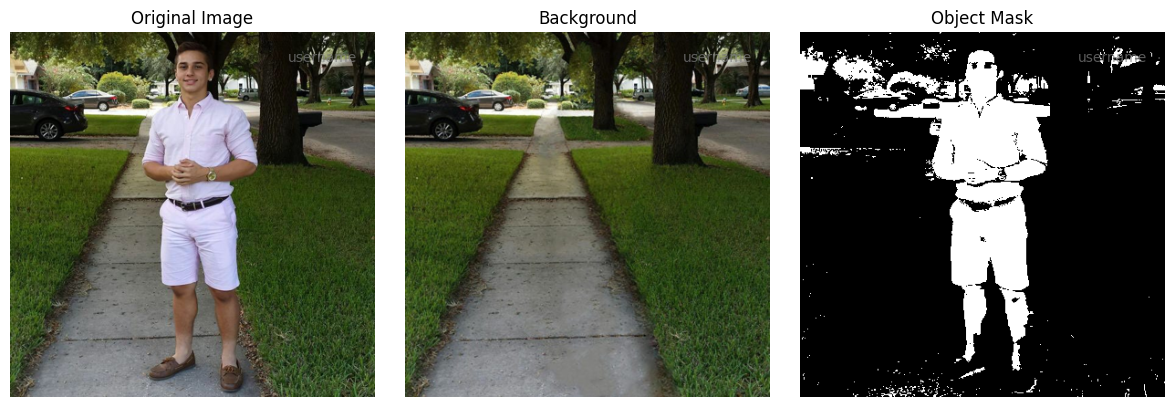

In [8]:
# Select threshold as a low percentile of background densities
threshold = np.percentile(background_densities, 5)
print("Chosen density threshold (5th percentile):", threshold)

# Predict densities for all pixels in the test image
test_densities = kde_bg.predict(test_features)

# Low density => foreground
foreground_mask = (test_densities < threshold).reshape(H, W)

print("Foreground pixels:", int(foreground_mask.sum()))
print("Background pixels:", int(foreground_mask.size - foreground_mask.sum()))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(test_img)
plt.title("Original Image")
plt.axis("off")
add_username()

plt.subplot(1, 3, 2)
plt.imshow(background_img)
plt.title("Background")
plt.axis("off")
add_username()

plt.subplot(1, 3, 3)
plt.imshow(foreground_mask, cmap="gray")
plt.title("Object Mask")
plt.axis("off")
add_username()

plt.tight_layout()
plt.show()


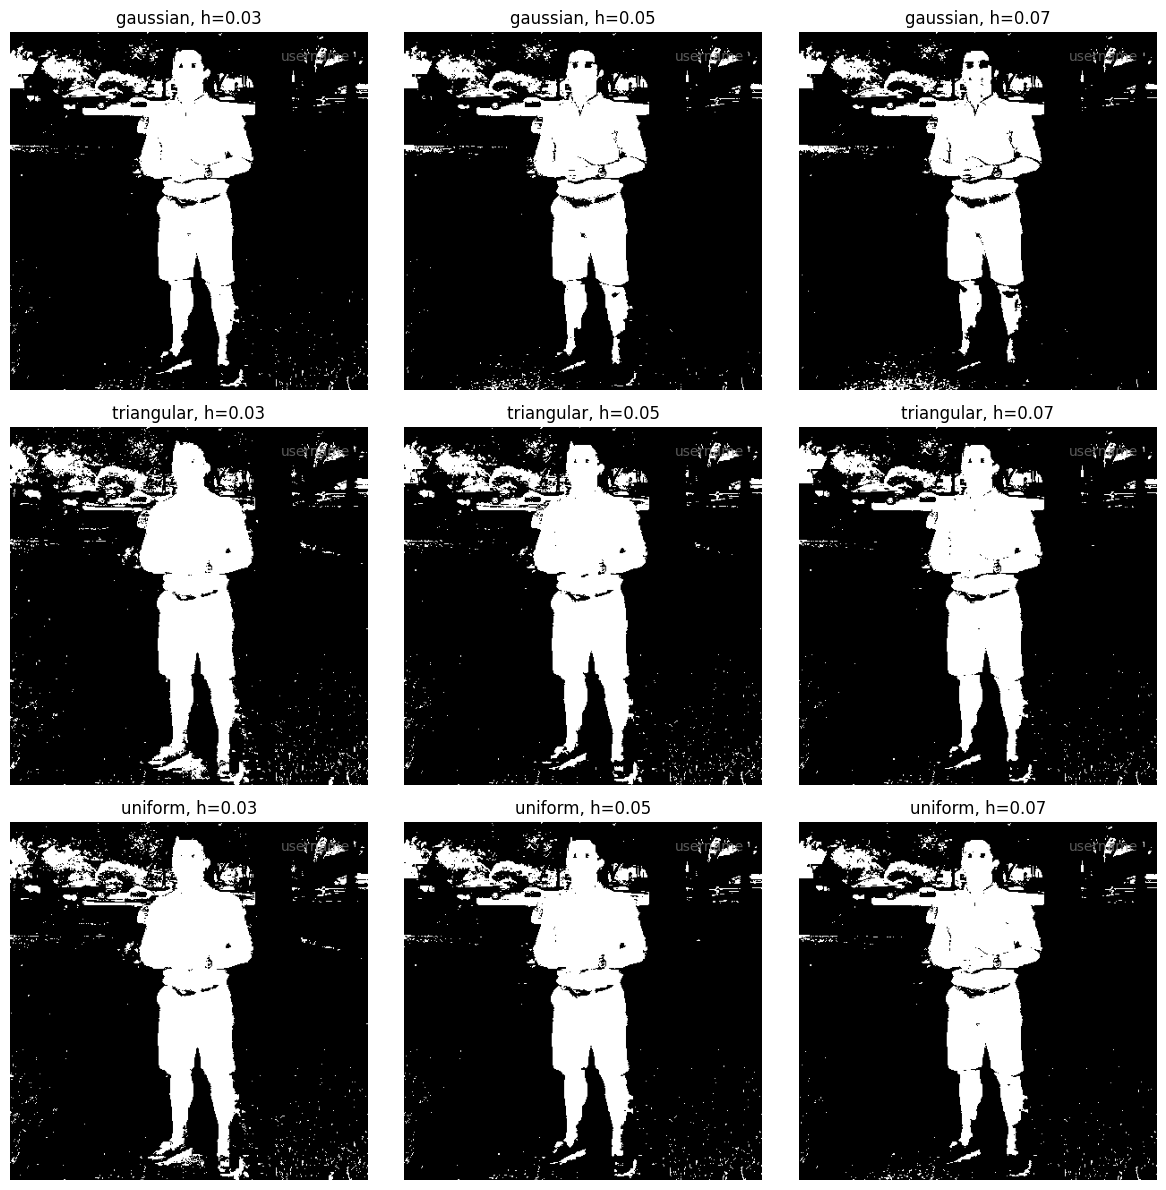

In [9]:
kernels = ["gaussian", "triangular", "uniform"]
bandwidths = [0.03, 0.05, 0.07]

fig, axes = plt.subplots(len(kernels), len(bandwidths),
                         figsize=(4 * len(bandwidths), 4 * len(kernels)))

for i, ker in enumerate(kernels):
    for j, bw in enumerate(bandwidths):
        kde_tmp = CustomKDE(
            kernel=ker, bandwidth=bw,
            max_samples=15000, batch_size=5000,
            random_state=42
        )
        kde_tmp.fit(background_features)

        bg_d = kde_tmp.predict(background_features)
        thr = np.percentile(bg_d, 5)

        tst_d = kde_tmp.predict(test_features)
        mask = (tst_d < thr).reshape(H, W)

        ax = axes[i, j]
        ax.imshow(mask, cmap="gray")
        ax.set_title(f"{ker}, h={bw}")
        ax.axis("off")
        ax.text(
            0.95, 0.95, USERNAME,
            ha='right', va='top',
            transform=ax.transAxes,
            fontsize=10, color='gray', alpha=0.7
        )

plt.tight_layout()
plt.show()


### 1.3 Foreground Detection – Kernel and Bandwidth Choice

To segment the foreground, we fit a KDE model on background pixel features and then
classify test pixels as foreground whenever their density under this model is below
a threshold (5th percentile of background densities).  
We experimented with three kernels — **gaussian**, **triangular**, and **uniform** —
and three bandwidths **h ∈ {0.03, 0.05, 0.07}**.

---

#### Observations from the segmentation masks

- **Bandwidth h = 0.03**
  - All kernels produce a lot of small noisy regions in the background
    (“salt-and-pepper” noise).
  - The foreground silhouette is present but has jagged boundaries and
    scattered false positives around it.
  - The KDE is too “sharp”, overfitting local noise in the background.

- **Bandwidth h = 0.07**
  - Foreground is smoother, but parts of the background with colors similar
    to the person (e.g., bright highlights) are also classified as foreground.
  - The model becomes too smooth, causing **over-segmentation of background**
    and loss of fine details.

- **Bandwidth h = 0.05**
  - For the **gaussian kernel**, the person’s silhouette is clean, mostly
    connected, and backgrounds are largely suppressed.
  - Triangular and uniform kernels at this bandwidth still show more noise and
    small holes inside the body, especially in textured areas.
  - This setting gives the best trade-off between removing noise and preserving
    the shape of the foreground object.

---

#### Why gaussian, h = 0.05 works best

1. **Smooth modeling of background color distribution**  
   The gaussian kernel produces a smooth, differentiable estimate of the
   background density. This is well suited to natural images where the
   background colors vary gradually (e.g., grass, trees, sky). Triangular and
   uniform kernels are piecewise linear/constant and react more harshly to
   small color changes, which shows up as speckle noise in the masks.

2. **Balanced bandwidth**  
   - At **h = 0.03**, each background pixel only influences a very small region
     in feature space, so the KDE becomes spiky and sensitive to noise or
     illumination variations. Many background pixels get very low density and
     are wrongly labeled as foreground.  
   - At **h = 0.07**, the density is overly smoothed; pixels with colors close
     to the foreground still get reasonably high background density, so parts
     of the object may be missed or merged with the background.  
   - **h = 0.05** provides a middle ground: it smooths out high-frequency
     noise while still preserving the separation between the person’s colors
     and the background colors.

3. **Robust thresholding**  
   With gaussian, h = 0.05, the distribution of background densities is
   well-concentrated. Choosing the 5th percentile as threshold cleanly separates
   “typical” background pixels from outliers. For the other kernels, the
   density distribution is broader and noisier, making the same percentile
   threshold less reliable.

---

#### Conclusion

Based on visual quality and the noise/coverage trade-off, the combination
**gaussian kernel with bandwidth h = 0.05** gives the **best segmentation**:

- Clear and contiguous foreground silhouette  
- Minimal false positives in the background  
- Good robustness to small background color variations

This justifies selecting (kernel = gaussian, h = 0.05) as the preferred KDE
configuration for foreground detection in this task.
